In [ ]:
from grid_world import GridWorldEnv
from dynamic_programming import value_iteration
from mdp import extract_mdp
import numpy as np
import matplotlib.pyplot as plt

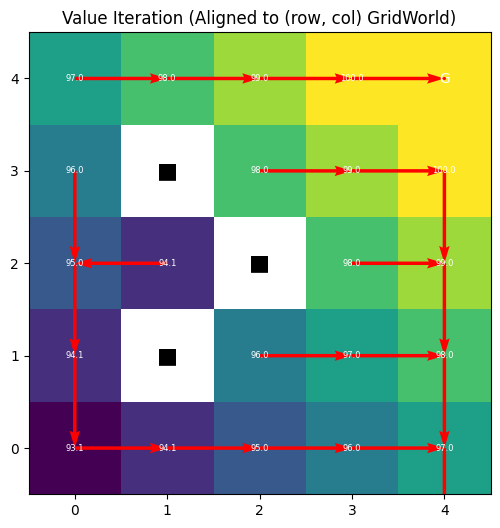

In [ ]:
# Create new environment with (row, col) coordinates
env_rc = GridWorldEnv(rows=5, cols=5, obstacles={(1, 1), (2, 2), (3, 1)})
states_rc, actions_rc, P_rc = extract_mdp(env_rc)

# Re-run value iteration
V_rc, pi_rc, iters_rc = value_iteration(states_rc, actions_rc, P_rc)

# Convert value and policy into grid for rendering
value_grid_rc = np.full((env_rc.rows, env_rc.cols), np.nan)
arrow_u_rc = np.zeros_like(value_grid_rc)
arrow_v_rc = np.zeros_like(value_grid_rc)
dir_map_rc = {0: (-1, 0), 1: (0, 1), 2: (1, 0), 3: (0, -1)}

for (r, c), v in V_rc.items():
    value_grid_rc[r, c] = v
    if (r, c) not in env_rc.obstacles and (r, c) != env_rc.goal_state:
        dr, dc = dir_map_rc[pi_rc[(r, c)]]
        arrow_u_rc[r, c] = dc
        arrow_v_rc[r, c] = -dr  # flip vertically for plotting

# Plot the result
plt.figure(figsize=(6, 6))
plt.imshow(value_grid_rc, origin="upper", cmap="viridis")

for r in range(env_rc.rows):
    for c in range(env_rc.cols):
        coord = (r, c)
        if coord in env_rc.obstacles:
            plt.text(c, r, "■", ha="center", va="center", fontsize=16, color="black")
        elif coord == env_rc.goal_state:
            plt.text(c, r, "G", ha="center", va="center", fontsize=10, color="white")
        elif not np.isnan(value_grid_rc[r, c]):
            plt.text(
                c,
                r,
                f"{value_grid_rc[r, c]:.1f}",
                ha="center",
                va="center",
                fontsize=6,
                color="white",
            )

plt.quiver(
    np.arange(env_rc.cols),
    np.arange(env_rc.rows),
    arrow_u_rc,
    arrow_v_rc,
    angles="xy",
    scale_units="xy",
    scale=1,
    color="red",
)

plt.title("Value Iteration (Aligned to (row, col) GridWorld)")
plt.xticks(np.arange(env_rc.cols))
plt.yticks(np.arange(env_rc.rows))
plt.grid(False)
plt.gca().invert_yaxis()  # Ensures (0,0) at bottom-left
plt.show()